In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
from pytickersymbols import PyTickerSymbols
from pandas_datareader import data as pdr
import yfinance as yf
yf.pdr_override()

In [216]:
%matplotlib inline
plt.rcParams["figure.dpi"] = 120 #Adjust the image quality

The following is used to download data: Yahoo finance with pandas. 

Link yahoo finance wiki:  https://github.com/ranaroussi/yfinance/wiki/Tickers

Yahoofinance pandas : https://pypi.org/project/yfinance/

valid values for period = [1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max]

## Part 1 Explanation


This part retrieves data on the opening prices of the stocks in stocks from the internet and plots the development of these prices for at least five stocks. This is done through five functions:
normalize_data normalizes the entries of the input matrix p so all stocks have a price of 1 the first day in the period, corresponding to the first entry in each column in p. This solves the issue of the low priced stocks being virtually flat when plotted against higher priced stocks.


The function plot_all plots all stocks in the same graph. It is called from within get_prices, and uses the price matrix p corresponding to the stocks given as input to get_prices. The arguments step_size, period, and normalize are also passed on from get_prices. If normalize is set to True, the prices from normalize_data are used in the plot, which makes it easier to compare movements in stock prices. plot_all uses that p is a data frame, so the plot is easily created with plot() from pandas. The title is customized through the use of a dictionary and an if statement to display the period, time step and whether or not the normalized data is used, to enhance readability.

The prices of stocks are imported using the pandas_datareader module. After selecting the opening prices columns, any NaNs are dropped to avoid trouble with bank holidays differing across countries. It has not been possible to test whether or not the imported stock prices are correct.

In [217]:
#PART 1 (get_prices and plot_all are the main functions. Normalize_data is not mandataroy, but is included
# to make the plot look nice)
def normalize_data(p):
    """Takes a matrix p of prices as input, and returns a matrix where all
    prices are normalized such that price at timestep zero is 1 USD.
    """
    normal = p.apply(lambda x: x / x[0], axis=0)
    return normal


def plot_all(p,
             step_size='d',
             period=('2017-04-26', '2022-04-26'),
             normalize=False):
    """Makes a plot with movemens in price for all stocks"""
    interval = {'1d': 'Daily', '5d': 'Weekly', '1mo': 'Monthly'}
    if normalize:
        p = normalize_data(p)
        title = (f"{interval[step_size]} normalized opening "
                 f"prices from {period[0]} to {period[1]}")
    else:
        title = (f"{interval[step_size]} opening prices "
                 f"from {period[0]} to {period[1]}")
    plt.figure()
    p.plot()
    plt.ylabel("US Dollars", fontsize=6)
    plt.xlabel('Date', fontsize=6)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.title(title, fontsize=9)
    plt.legend(title="Ticker", fontsize=6)
    plt.grid(True, alpha=0.3)

    plt.show()
    
def get_prices(stocks,
               step_size='1d',
               period=('2017-04-26', '2023-04-26'),
               makeplot=False,
               normalize=False):
    data = pdr.get_data_yahoo(stocks,
                              start=period[0],
                              end=period[1],
                              interval = step_size)
    p = data['Open'].dropna(axis=0)
    
    if makeplot:
        plot_all(p,
                 step_size=step_size,
                 period=period,
                 normalize=normalize)
    return (stocks, p)


[*********************100%***********************]  6 of 6 completed


<Figure size 768x576 with 0 Axes>

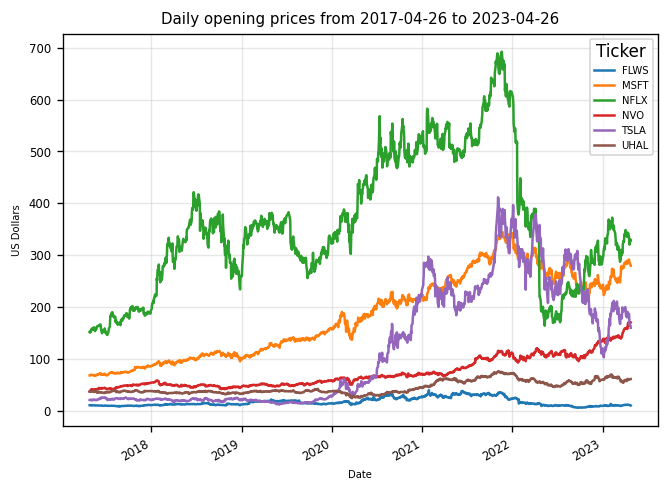

In [218]:
S = ['MSFT', 'NVO', 'FLWS', 'NFLX', 'UHAL', 'TSLA']
(stocks, p) = get_prices(S, makeplot=True)

[*********************100%***********************]  6 of 6 completed


<Figure size 768x576 with 0 Axes>

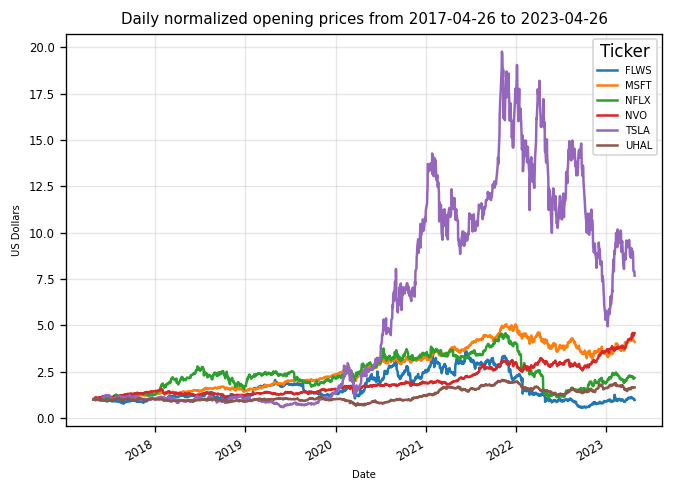

In [219]:
(stocks, p) = get_prices(S, makeplot=True,normalize=True)

From the normalized plot we e.g., see that in 2021 the TSLA price had almost 20 doubled since 2018

## Part 2
In this part, it is assumed that returns are normally distributed. Estimates of means and variances of returns on stocks are calculated, and the empirical density functions for all stocks are plotted. This part consists of two functions:
densityplots plots the estimated PDFs of the stocks. We use the function norm.pdf from scipy to calculate PDFs. To scale the x-axis to show every density-function in the same plot, we define variables x_max, y_max that together with linspace from numpy defines the range and the values of the axis. We use the function norm.ppf from scipy to calculate the 0.05 and 0.95 quantiles of a normal distribution, and use the largest variance of all portfolios and the largest and smallest mean-value respectively. To get enough x-ticks to make the function look smooth, we pass 1000 as argument to linspace.

get_estimates calculates the estimates for the optimization problem, i.e. r, μ and Σ, using the formulas from the project description in brightspace. The calculations are done most easily using numpy, so the dataframe p is converted to a numpy object. If makeplot is set to True, the function densityplots is invoked. 

In [220]:
#PART 2

def densityplots(stocks, r, mu, sigma):
    """Makes plot with every density function"""
    sds = sigma.diagonal() ** 0.5
    scale = max(sds)
    x_min = norm.ppf(0.01,
                     loc=min(mu), scale=scale)
    x_max = norm.ppf(0.99,
                     loc=max(mu), scale=scale)

    x_axis = np.linspace(x_min, x_max, 1000)

    prob_max = max([norm.pdf(0, loc=mu[i], scale=sds[i])
                    for i in range(len(stocks))]) + 5
        
    for i, stock in enumerate(stocks):
        plt.plot(x_axis,
                 norm.pdf(x_axis, loc=mu[i], scale=sds[i]),
                 label=stock)
        plt.legend(fontsize=7, loc='center', bbox_to_anchor=(1, 0.5))
        plt.xlim(x_min, x_max)
        plt.ylim(0, prob_max) 


    title_of_plot = ("PDF's of All")
    plt.title(title_of_plot)
    plt.show()


def get_estimates(stocks, p, makeplot=False):
    """Returns stock returns for each time step as well as estimates of
    average returns and covariance for each stock."""

    p = p.to_numpy() #Numpy is easier to work with
    rows, cols = p.shape
    r = np.array([(p[j + 1] - p[j]) / p[j] for j in range(rows - 1)])
    mu = r.mean(axis=0)
    sigma = sum((np.outer(r[j] - mu, r[j] - mu)
                for j in range(rows - 1))) / rows

    if makeplot:
        densityplots(stocks, r, mu, sigma)

    return (r, mu, sigma)


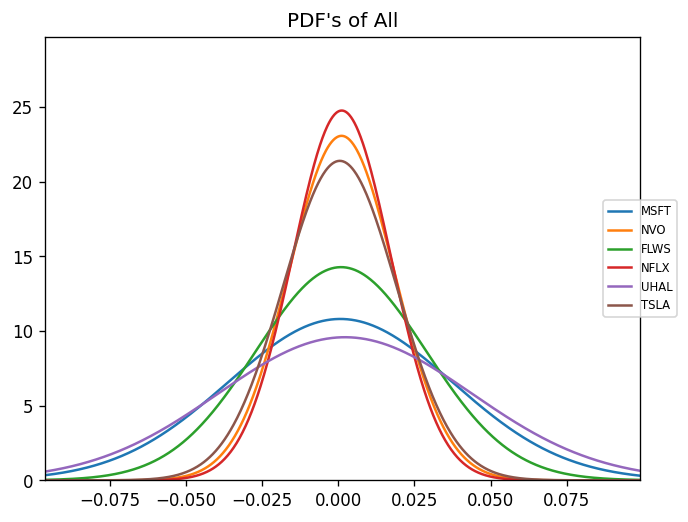

In [ ]:
(r, mu, sigma) = get_estimates(stocks, p, makeplot=True)

## Part 3

In this part, the optimization problem is solved, and the optimal portfolio is returned as a data frame. The PDFs and composition of the optimal portfolios for various values of γ are also plotted. For this, four functions are used:

The function solver solves the maximization problem using minimize from scipy. The first argument to minimize is an object function, which is defined inside the scope of solver as obj(w). Maximizing is equivalent to minimizing the object function multiplied by −1. The portfolio with equal weights is a reasonable starting point for the algorithm, so this is passed as the second argument to minimize. The last
3
argument is a dictionary which states that the constraint is an equality as well as the constraint itself, using a lambda expression, that sums the weights in w and subtracts 1, because the right hand side of the constraint must be 0. The algorithm used is SLSQP, as this was able to handle linear constraints. However, minimize does not always return the correct optimum, but it usually does. solver returns the optimal portfolio as a numpy array, since these are easier to use in calculations.


The function optimal_pdfs uses solver to calculate the optimal portfolio for different values of γ, and then plots the PDFs for the returns of those. To ease notation when calling the function, gammas has been given a default value. Inside the function, list comprehensions are used to calculate the mean and variance of the optimal portfolio for each value of γ. The @ operator from numpy is used to do matrix multiplication. In the list comprehensions, solver is invoked three times for each γ. This could be made more efficient using a for loop and the append() method. However, the approach used in the code was deemed more intuitive and compact.

The scatter plot is made using plt.scatter()


The PDF plot of the optimal portfolios for different values og γ shows that the more risk averse, that is the higher value of γ, the smaller variance the portfolio has, which makes sense. The scatter plot tells the same story; the higher γ, the more equally weighted the portfolio is, which again results in a smaller variance.

In [222]:
def solver(r, mu, sigma, gamma):
    """Solves for the optimal portfolio of the stocks that were used to generate
    the estimates of r, mu and sigma, when the
    risk aversion parameter is gamma."""
    
    rows, cols = r.shape

    def obj(w):
        value = w.T @ mu - gamma * w.T @sigma @ w
        return - value
    
    start = np.full(cols, 1 / cols)
    w_star = minimize(obj,
                      start,
                      constraints={'type': 'eq', 'fun': lambda w: sum(w) - 1},
                      method='SLSQP').x

    return w_star


def optimal_pdfs(r, mu, sigma, gammas=(np.arange(10) / 5) + 1):
    """Makes a plot of PDF'S of the optimal portfolio of the stocks,
    that were used to generate the estimates of r, mu and sigma
    for different values of gamma. """
    
    means = [solver(r, mu, sigma, gamma) @ mu for gamma in gammas]
    var = [solver(r, mu, sigma, gamma) @ sigma
           @ solver(r, mu, sigma, gamma) for gamma in gammas]

    x_min = norm.ppf(0.05,
                     loc=min(means), scale=max(var)**0.5)
    x_max = norm.ppf(0.95,
                     loc=max(means), scale=max(var)**0.5)

    x_axis = np.linspace(x_min, x_max, 1000)

    for indx, gamma in enumerate(gammas):
        plt.plot(x_axis,
                 norm.pdf(x_axis, loc=means[indx], scale=var[indx] ** 0.5),
                 label=(f'$\gamma = ${gamma}, $\mu = ${means[indx]:.2E}, '
                        f'$\sigma^2 = ${var[indx]:.2E}'))
        plt.legend(fontsize=7)

    plt.title("PDFs of optimal portfolios with estimated mean and variances")

    plt.show()

   


def optimal_portfolio(stocks,
                      gamma, r, mu, sigma):
    """Calculates and plots the PDF's and portfolio weights of
    the optimal portfolio of the stocks for at specific value
    of gamma as well as a scatter plot of the composition of the optimal
    portfolio for different risk aversion parameters. Returns the optimal portfolio as a dataframe.
    """
    optimal_pdfs(r, mu, sigma)
  

    w_star = solver(r, mu, sigma, gamma)
    optimal_port = pd.DataFrame([w_star], columns=stocks)

   
    gammas = (np.arange(10) / 5) + 1
    weights = [solver(r, mu, sigma, gamma) for gamma in gammas]
    for stock in range(len(stocks)):
        plt.scatter(gammas,
                    [weights[i][stock] for i in range(len(gammas))],
                    label=stocks[stock])
        #print([weights[i][stock] for i in range(len(gammas))])

    plt.xlabel('Gamma')
    plt.ylabel('Portfolio share')
    plt.legend(fontsize=8)
    plt.show()

    return optimal_port



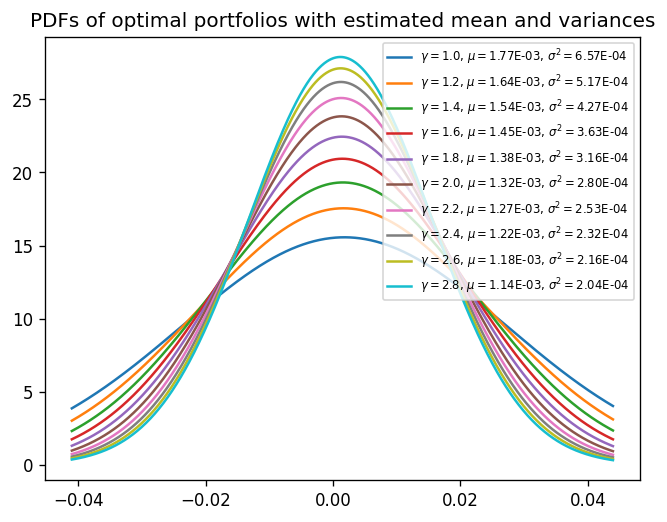

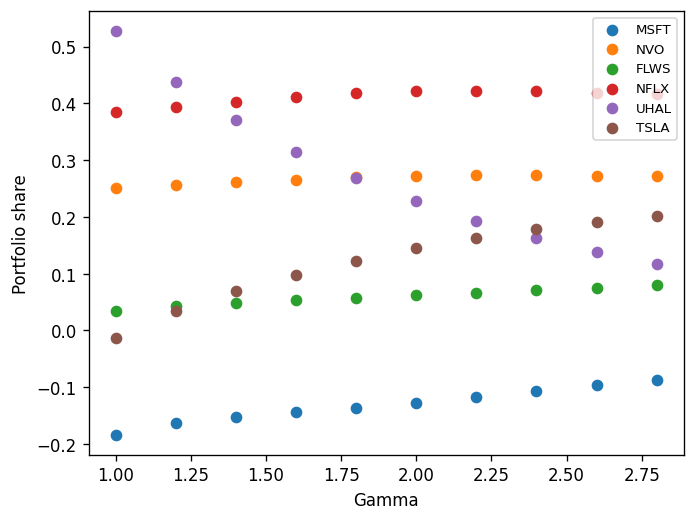

In [223]:
# Example (with gamma = 1)
optimal = optimal_portfolio(stocks, 1, r, mu, sigma)

From this we, for example, see that when risk aversion increases the share of UHAL stocks in the portfolio drops. 

In [224]:
#Optimal portfolio:
optimal

,MSFT,NVO,FLWS,NFLX,UHAL,TSLA
0,-0.183227,0.250711,0.033525,0.385172,0.526899,-0.01308


The optimal portfolio consists for example of 25 percent bought shares of NVO and 18 percent shorted shares of MSFT